In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as optimization

In [2]:
# on average there are 252 trading days in a year
NUM_TRADING_DAYS = 252
# we will generate random w (different portfolios)
NUM_PORTFOLIOS = 10000

# stocks we are going to handle
stocks = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN', 'DB']

# historical data - define START and END dates
start_date = '2010-01-01'
end_date = '2017-01-01'

In [5]:
# name of the stock (key) - stock values (2010-1017) as the values
stock_data = {}

for stock in stocks:
    # closing prices
    ticker = yf.Ticker(stock)
    stock_data[stock] = ticker.history(start=start_date, end=end_date)['Close']

data = pd.DataFrame(stock_data)

In [9]:
data.tail(5)

,AAPL,WMT,TSLA,GE,AMZN,DB
Date,,,,,,
2016-12-23 00:00:00-05:00,27.007303,20.115482,14.222667,140.250885,38.029499,16.517509
2016-12-27 00:00:00-05:00,27.178831,20.161764,14.635333,140.338898,38.570000,16.286991
2016-12-28 00:00:00-05:00,27.062939,20.048950,14.649333,139.459045,38.606499,15.888018
2016-12-29 00:00:00-05:00,27.055979,20.034485,14.312000,139.503052,38.257500,15.799356
2016-12-30 00:00:00-05:00,26.845062,19.993992,14.246000,139.019135,37.493500,16.047606


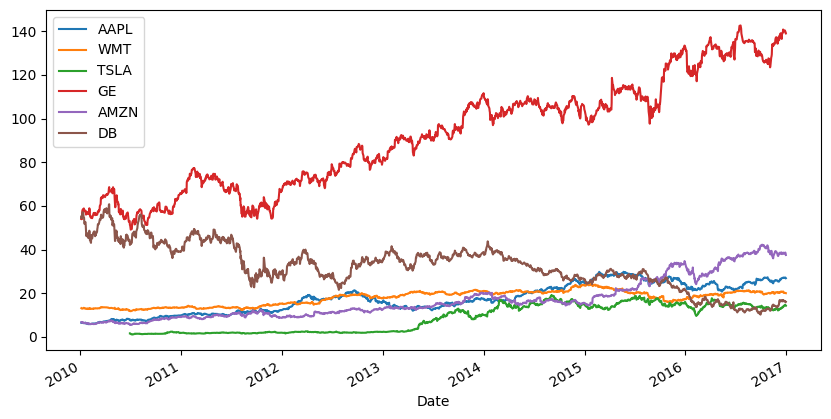

In [6]:
data.plot(figsize=(10, 5))
plt.show()

In [7]:
# NORMALIZATION - to measure all variables in comparable metric
log_return = np.log(data / data.shift(1))
returns = log_return[1:]

In [11]:
returns.describe()

,AAPL,WMT,TSLA,GE,AMZN,DB
count,1761.000000,1761.000000,1639.000000,1761.000000,1761.000000,1761.000000
mean,0.000809,0.000240,0.001337,0.000537,0.000978,-0.000694
std,0.016523,0.010293,0.033033,0.013711,0.020324,0.026407
min,-0.131884,-0.105810,-0.214772,-0.067653,-0.135325,-0.192236
25%,-0.007436,-0.004946,-0.014951,-0.006497,-0.009201,-0.014074
50%,0.000886,0.000502,0.000810,0.000424,0.000577,-0.000318
75%,0.010275,0.005667,0.018166,0.007665,0.012175,0.014168
max,0.085022,0.091488,0.218292,0.102597,0.146225,0.165096


In [12]:
# instead of daily metrics we are after annual metrics
# mean of annual return
print(returns.mean() * NUM_TRADING_DAYS)
print(returns.cov() * NUM_TRADING_DAYS)

AAPL    0.203962
WMT     0.060359
TSLA    0.336881
GE      0.135330
AMZN    0.246535
DB     -0.174779
dtype: float64
          AAPL       WMT      TSLA        GE      AMZN        DB
AAPL  0.068795  0.009859  0.029641  0.021861  0.027812  0.036297
WMT   0.009859  0.026701  0.010949  0.013018  0.010755  0.020153
TSLA  0.029641  0.010949  0.274985  0.027283  0.047326  0.052331
GE    0.021861  0.013018  0.027283  0.047376  0.025830  0.054800
AMZN  0.027812  0.010755  0.047326  0.025830  0.104095  0.045055
DB    0.036297  0.020153  0.052331  0.054800  0.045055  0.175733


In [13]:
portfolio_means = []
portfolio_risks = []
portfolio_weights = []

for _ in range(NUM_PORTFOLIOS):
    w = np.random.random(len(stocks))
    w /= np.sum(w)
    portfolio_weights.append(w)
    portfolio_means.append(np.sum(returns.mean() * w) * NUM_TRADING_DAYS)
    portfolio_risks.append(np.sqrt(np.dot(w.T, np.dot(returns.cov() * NUM_TRADING_DAYS, w))))

pweights, means, risks = np.array(portfolio_weights), np.array(portfolio_means), np.array(portfolio_risks)

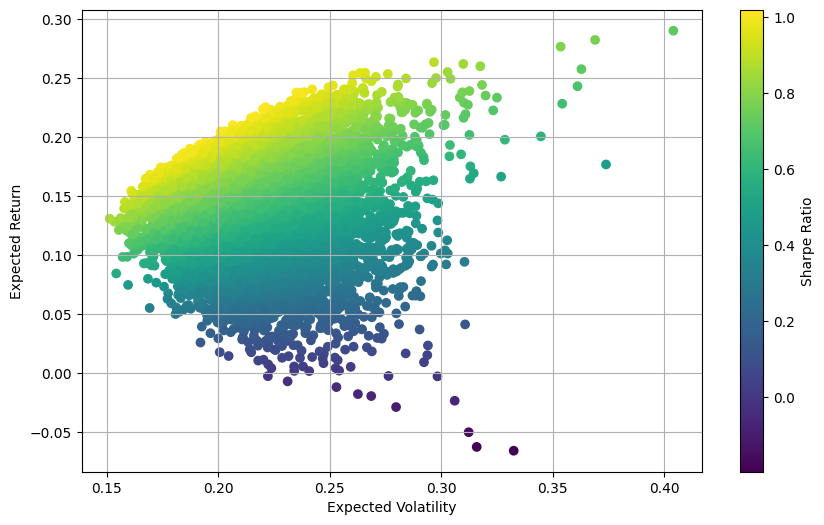

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(risks, means, c=means / risks, marker='o')
plt.grid(True)
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.show()

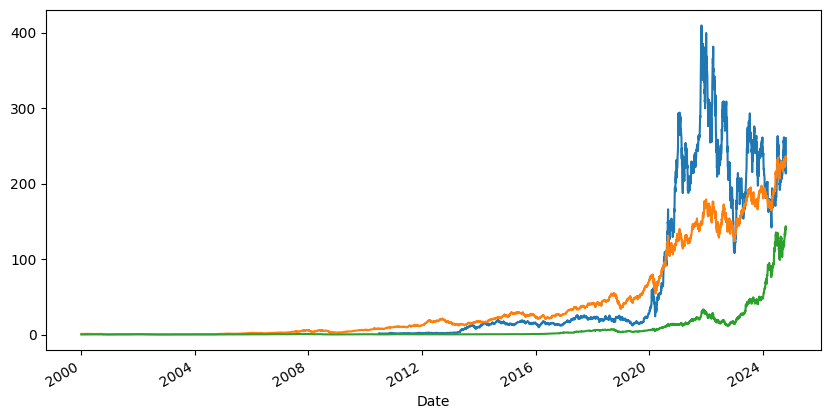

In [30]:
yf.Ticker('TSLA').history(start='2000-01-01')['Close'].plot(figsize=(10, 5))
yf.Ticker('AAPL').history(start='2000-01-01')['Close'].plot(figsize=(10, 5))
yf.Ticker('NVDA').history(start='2000-01-01')['Close'].plot(figsize=(10, 5))
plt.show()

In [16]:

def download_data():
    # name of the stock (key) - stock values (2010-1017) as the values
    stock_data = {}

    for stock in stocks:
        # closing prices
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)['Close']

    return pd.DataFrame(stock_data)


def show_data(data):
    data.plot(figsize=(10, 5))
    plt.show()


def calculate_return(data):
    # NORMALIZATION - to measure all variables in comparable metric
    log_return = np.log(data / data.shift(1))
    return log_return[1:]


def show_statistics(returns):
    # instead of daily metrics we are after annual metrics
    # mean of annual return
    print(returns.mean() * NUM_TRADING_DAYS)
    print(returns.cov() * NUM_TRADING_DAYS)


def show_mean_variance(returns, weights):
    # we are after the annual return
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()
                                                            * NUM_TRADING_DAYS, weights)))
    print("Expected portfolio mean (return): ", portfolio_return)
    print("Expected portfolio volatility (standard deviation): ", portfolio_volatility)


def show_portfolios(returns, volatilities):
    plt.figure(figsize=(10, 6))
    plt.scatter(volatilities, returns, c=returns / volatilities, marker='o')
    plt.grid(True)
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.show()


def generate_portfolios(returns):
    portfolio_means = []
    portfolio_risks = []
    portfolio_weights = []

    for _ in range(NUM_PORTFOLIOS):
        w = np.random.random(len(stocks))
        w /= np.sum(w)
        portfolio_weights.append(w)
        portfolio_means.append(np.sum(returns.mean() * w) * NUM_TRADING_DAYS)
        portfolio_risks.append(np.sqrt(np.dot(w.T, np.dot(returns.cov()
                                                          * NUM_TRADING_DAYS, w))))

    return np.array(portfolio_weights), np.array(portfolio_means), np.array(portfolio_risks)


def statistics(weights, returns):
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * NUM_TRADING_DAYS, weights)))
    return np.array([portfolio_return, portfolio_volatility, portfolio_return / portfolio_volatility])


# scipy optimize module can find the minimum of a given function
# the maximum of a f(x) is the minimum of -f(x)
def min_function_sharpe(weights, returns):
    return -statistics(weights, returns)[2]


# what are the constraints? The sum of weights = 1 !!!
# f(x)=0 this is the function to minimize
def optimize_portfolio(weights, returns):
    # the sum of weights is 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    # the weights can be 1 at most: 1 when 100% of money is invested into a single stock
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    return optimization.minimize(fun=min_function_sharpe, x0=weights[0], args=returns, method='SLSQP', bounds=bounds, constraints=constraints)


def print_optimal_portfolio(optimum, returns):
    print("Optimal portfolio: ", optimum['x'].round(3))
    print("Expected return, volatility and Sharpe ratio: ", statistics(optimum['x'].round(3), returns))


def show_optimal_portfolio(opt, rets, portfolio_rets, portfolio_vols):
    plt.figure(figsize=(10, 6))
    plt.scatter(portfolio_vols, portfolio_rets, c=portfolio_rets / portfolio_vols, marker='o')
    plt.grid(True)
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.plot(statistics(opt['x'], rets)[1], statistics(opt['x'], rets)[0], 'g*', markersize=20.0)
    plt.show()

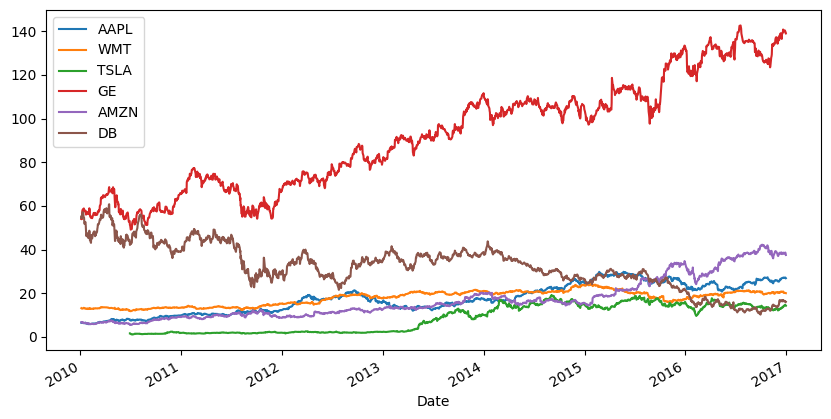

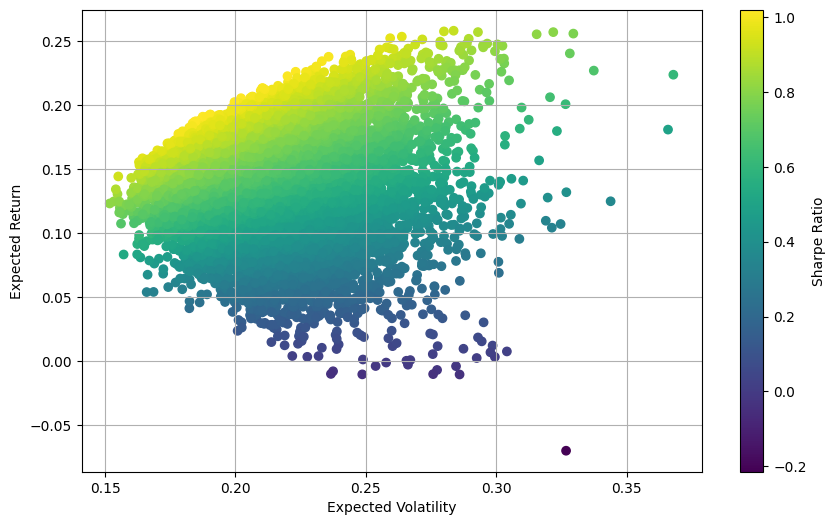

Optimal portfolio:  [0.363 0.076 0.141 0.155 0.264 0.   ]
Expected return, volatility and Sharpe ratio:  [0.21218697 0.20555033 1.03228717]


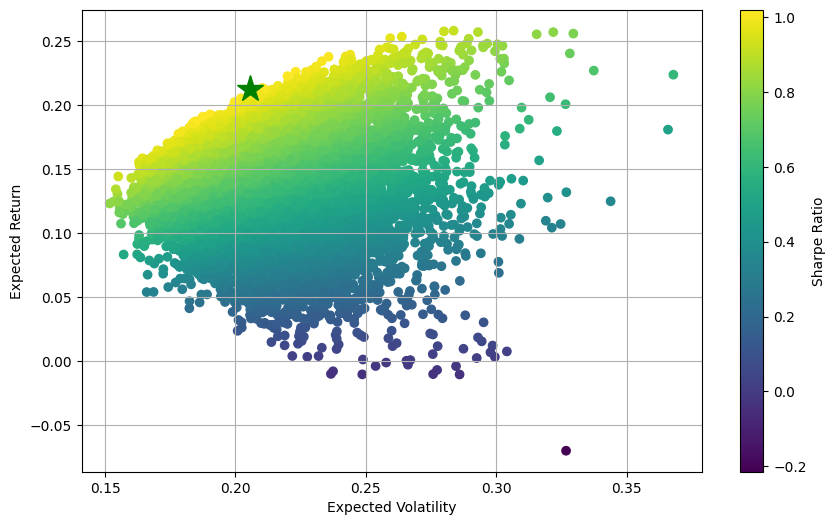

In [17]:
dataset = download_data()
show_data(dataset)
log_daily_returns = calculate_return(dataset)
# show_statistics(log_daily_returns)

pweights, means, risks = generate_portfolios(log_daily_returns)
show_portfolios(means, risks)
optimum = optimize_portfolio(pweights, log_daily_returns)
print_optimal_portfolio(optimum, log_daily_returns)
show_optimal_portfolio(optimum, log_daily_returns, means, risks)

In [18]:
pweights

array([[0.11230558, 0.0412444 , 0.0125813 , 0.37554013, 0.11432879,
        0.3439998 ],
       [0.2367579 , 0.04230668, 0.12989879, 0.05848052, 0.10602596,
        0.42653015],
       [0.13697464, 0.14358796, 0.11512701, 0.29615829, 0.12881999,
        0.17933212],
       ...,
       [0.26279185, 0.16303174, 0.08119961, 0.15378625, 0.23772639,
        0.10146416],
       [0.01453018, 0.23861365, 0.08225246, 0.1220149 , 0.31019679,
        0.23239202],
       [0.00966974, 0.01626883, 0.10065407, 0.31489418, 0.30013394,
        0.25837924]])

In [19]:
means

array([0.04851794, 0.05410837, 0.11588286, ..., 0.15248046, 0.09744475,
       0.10831155])

In [20]:
risks

array([0.23913974, 0.26240267, 0.20269388, ..., 0.19224902, 0.21414239,
       0.24017709])